In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import subspace_angles, svd

In [10]:
def dynamics(t, state, g=9.81, L=1.0):
    theta, thetadot = state
    thetaddot = -(g / L) * np.sin(theta)
    return [thetadot, thetaddot]

def sim(theta0, thetadot0, t=10, dt=0.01, g=9.81, L=1.0):
    t_span = (0, t)
    t_eval = np.arange(0, t, dt)
    
    # Solve the ODE
    solution = solve_ivp(
        dynamics, 
        t_span, 
        [theta0, thetadot0], 
        args=(g, L), 
        t_eval=t_eval,
        rtol=1e-9,  # High precision to conserve energy in simulation
        atol=1e-9
    )
    
    return solution.t, solution.y.T

In [ ]:
def hankel_kernel_shift(X, Y, k, gamma=1.0):
    """
    X: (samples, n)
    Y: (samples, n)
    """
    G = polynomial_kernel(X, Y, degree=gamma) 
    
    N_rows = G.shape[0] - k + 1
    K_H = np.zeros((N_rows, N_rows))
    
    for tau in range(k):
        K_H += G[tau : tau + N_rows, tau : tau + N_rows]
        
    return K_H

def subkern(x: np.ndarray, y: np.ndarray, k: int, n: int, gamma=1.0, reg=1e-5):
    """
    x, y: input trajectories
    k: history
    n: system order
    """
    K_XX = hankel_kernel_shift(x, x, k, gamma)
    K_XY = hankel_kernel_shift(x, y, k, gamma)
    K_YY = hankel_kernel_shift(y, y, k, gamma)

    lam1, V1 = eigsh(K_XX + reg * np.eye(K_XX.shape[0]), k=n, which='LM')
    lam2, V2 = eigsh(K_YY + reg * np.eye(K_YY.shape[0]), k=n, which='LM')
    idx1 = np.argsort(lam1)[::-1]
    idx2 = np.argsort(lam2)[::-1]
    
    lam1, V1 = lam1[idx1], V1[:, idx1]
    lam2, V2 = lam2[idx2], V2[:, idx2]

    W1 = V1 * (lam1 ** -0.5)
    W2 = V2 * (lam2 ** -0.5)
    
    S = W1.T @ K_XY @ W2
    return np.linalg.norm(S)**2

## Tests on coupled linear oscillators

In [3]:
from experiments.coupled_lin_osc import *

In [25]:
task = CoupledLinearOsc(CLO_CFG['clo1'])
x_tr, x_te, y_te = task.get_train_test()

Gen. train w/ shape (250, 100, 50) and test w/ shape (500, 100, 50)


In [39]:
get_hankel(x_te[0], hist=1)

ValueError: could not broadcast input array from shape (100,50) into shape (100,)

In [33]:
subspace_similarity(x_te[0], x_te[1], hist=60, n_modes=10)

ValueError: could not broadcast input array from shape (41,50) into shape (41,)

## Tests on the pendulum

kernel: 2.0000000000000013
1.0


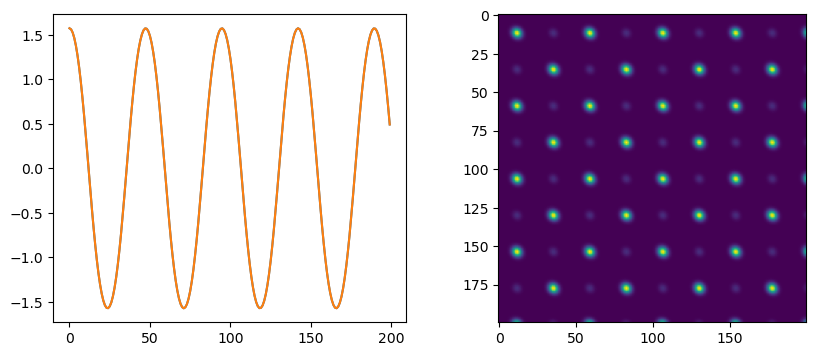

In [335]:
k = 1
gamma=10

t, x = sim(np.pi/2, 0, L=1, dt=0.05)
t, y = sim(np.pi/2, 0, L=1, dt=0.05)

#y += 0.1 * t[:, np.newaxis]

print(f'kernel: {subkern(x, y, k=k, n=2, gamma=gamma)}')
print(subspace_similarity(x[:,0], y[:,0], embed_dim=20, n_modes=20))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(x[:,0])
ax[0].plot(y[:,0])

K = hankel_kernel_shift(x, y, k=k, gamma=gamma)
plt.imshow(K)

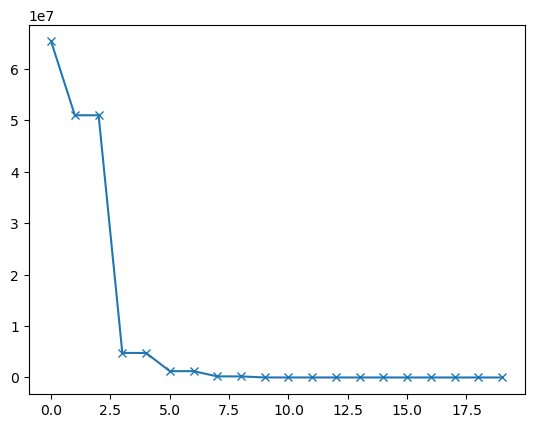

In [240]:
num_eigs = 20
plt.plot(range(num_eigs), np.abs(np.linalg.eigvals(K)[:num_eigs]), marker='x')

/Users/ljn/anaconda3/envs/cd_project/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ljn/anaconda3/envs/cd_project/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


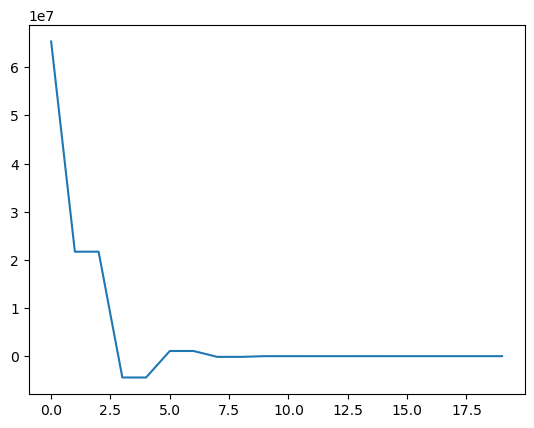

In [241]:
plt.plot(eigs(K, k=20)[0])

In [179]:
ks = np.linspace(1, 100, num=20)
vals = [subkern(x, y, k=int(ki)) for ki in ks]

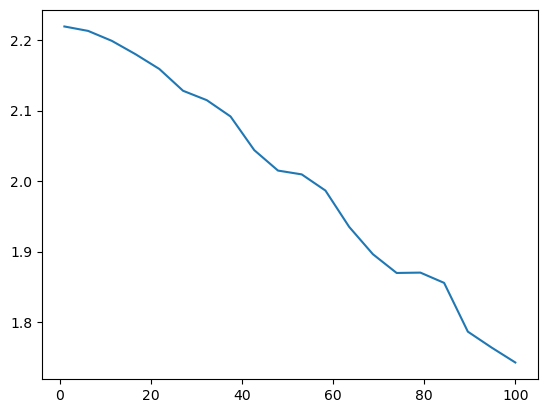

In [180]:
plt.plot(ks, vals)